In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.stats as st

matplotlib.rcParams['pdf.fonttype'] = 42

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/Integrated_MPN_scvi_genotyped_nb.h5ad')
cell_cycle_df = pd.read_csv('../data/MPN_patients_cell_cycle_scores.csv', index_col=0)
adata.obs = adata.obs.merge(cell_cycle_df[['S_score','G2M_score','phase']], left_index=True, right_index=True)


In [3]:
patient_metadata = pd.read_csv('../../5_figure_MPN_JAK2/data/patient_diagnoses.csv')

homozygous_mrvi_path = large_data_dir + 'MPN_WTA/homozygous_JAK2_mrvi_patient_as_nuisance.h5ad'
homozygous_jak2_patients = sc.read_h5ad(homozygous_mrvi_path).obs['sample'].unique()

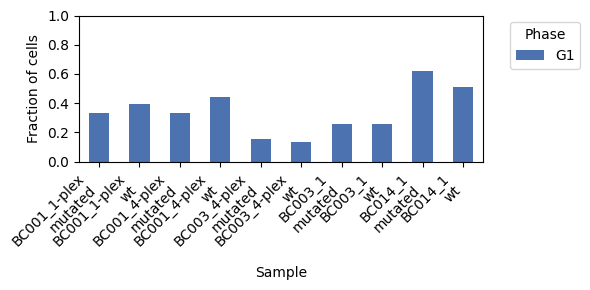

In [4]:
cell_type = 'HSC'
min_cells = 25

adata_subset = adata[adata.obs['cell_type'] == cell_type, :].copy()
adata_subset = adata_subset[adata_subset.obs['genotype'].isin(['JAK2 c.1849G>T_mutated', 'JAK2 c.1849G>T_wt','JAK2 c.1849G>T_heterozygous'])].copy()

### find samples with at least min cells in both mutated and wt groups
genotypes = ['JAK2 c.1849G>T_mutated','JAK2 c.1849G>T_heterozygous']
samples_to_include = adata_subset[adata_subset.obs['genotype'].isin(genotypes)].obs['sample'].value_counts()
samples_to_include = samples_to_include[samples_to_include >= min_cells].index.tolist()
genotypes = ['JAK2 c.1849G>T_wt']
samples_to_include = adata_subset[(adata_subset.obs['genotype'].isin(genotypes)) & (adata_subset.obs['sample'].isin(samples_to_include))].obs['sample'].value_counts()
samples_to_include = samples_to_include[samples_to_include >= min_cells].index.tolist()
adata_subset.obs['JAK2_genotype'] = adata_subset.obs['genotype'].map({'JAK2 c.1849G>T_heterozygous':'mutated', 'JAK2 c.1849G>T_mutated':'mutated', 'JAK2 c.1849G>T_wt':'wt'})

### get counts of cells in each phase per sample and genotype
phase_counts = adata_subset.obs[['sample','JAK2_genotype','phase']].value_counts().reset_index().sort_values(['sample','JAK2_genotype'])

### reformat and plot samples that were in the homozygous JAK2 mrvi set (all others would have too many heterozygous cells)
df = phase_counts.loc[phase_counts['sample'].isin(set(samples_to_include).intersection(homozygous_jak2_patients))].reset_index(drop=True).copy()
df['sample'] = df['sample'].cat.remove_unused_categories()

# --- Combine sample + genotype for x-axis ---
df["group"] = df["sample"].astype(str) + "_" + df["JAK2_genotype"].astype(str)

# --- Pivot so phases become columns ---
pivot = df.pivot_table(index=["sample", "JAK2_genotype"], columns="phase", values="count", aggfunc="sum", observed=False).fillna(0)
pivot = pivot.div(pivot.sum(axis=1), axis=0)
pivot = 1 - pivot["G1"]  # order phases

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,3))
pivot.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0"])

# --- Beautify ---
xticks = [f"{s}\n{g}" for s, g in pivot.index]
ax.set_xticklabels(xticks, rotation=45, ha="right")
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Sample")
ax.legend(title="Phase", bbox_to_anchor=(1.05, 1), loc="upper left")

ax.set_ylim(0,1)
plt.tight_layout()

plt.savefig(f"../plots/{cell_type}_cell_cycle_by_sample_genotype_stacked_bar.pdf", bbox_inches='tight', dpi=300)

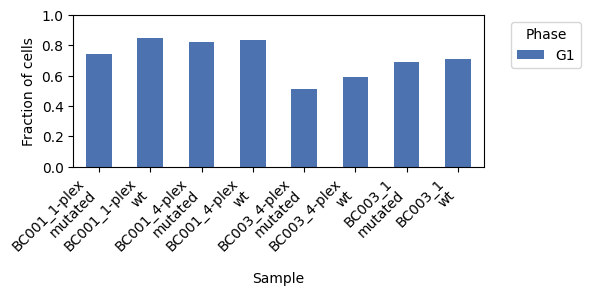

In [5]:
cell_type = 'Early MK'
min_cells = 25

adata_subset = adata[adata.obs['cell_type'] == cell_type, :].copy()
adata_subset = adata_subset[adata_subset.obs['genotype'].isin(['JAK2 c.1849G>T_mutated', 'JAK2 c.1849G>T_wt','JAK2 c.1849G>T_heterozygous'])].copy()

### find samples with at least min cells in both mutated and wt groups
genotypes = ['JAK2 c.1849G>T_mutated','JAK2 c.1849G>T_heterozygous']
samples_to_include = adata_subset[adata_subset.obs['genotype'].isin(genotypes)].obs['sample'].value_counts()
samples_to_include = samples_to_include[samples_to_include >= min_cells].index.tolist()
genotypes = ['JAK2 c.1849G>T_wt']
samples_to_include = adata_subset[(adata_subset.obs['genotype'].isin(genotypes)) & (adata_subset.obs['sample'].isin(samples_to_include))].obs['sample'].value_counts()
samples_to_include = samples_to_include[samples_to_include >= min_cells].index.tolist()
adata_subset.obs['JAK2_genotype'] = adata_subset.obs['genotype'].map({'JAK2 c.1849G>T_heterozygous':'mutated', 'JAK2 c.1849G>T_mutated':'mutated', 'JAK2 c.1849G>T_wt':'wt'})

### get counts of cells in each phase per sample and genotype
phase_counts = adata_subset.obs[['sample','JAK2_genotype','phase']].value_counts().reset_index().sort_values(['sample','JAK2_genotype'])

### reformat and plot samples that were in the homozygous JAK2 mrvi set (all others would have too many heterozygous cells)
df = phase_counts.loc[phase_counts['sample'].isin(set(samples_to_include).intersection(homozygous_jak2_patients))].reset_index(drop=True).copy()
df['sample'] = df['sample'].cat.remove_unused_categories()

# --- Combine sample + genotype for x-axis ---
df["group"] = df["sample"].astype(str) + "_" + df["JAK2_genotype"].astype(str)

# --- Pivot so phases become columns ---
pivot = df.pivot_table(index=["sample", "JAK2_genotype"], columns="phase", values="count", aggfunc="sum", observed=False).fillna(0)
pivot = pivot.div(pivot.sum(axis=1), axis=0)
pivot = 1 - pivot["G1"]  # order phases

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,3))
pivot.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0"])

# --- Beautify ---
xticks = [f"{s}\n{g}" for s, g in pivot.index]
ax.set_xticklabels(xticks, rotation=45, ha="right")
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Sample")
ax.legend(title="Phase", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

ax.set_ylim(0,1)
plt.savefig(f"../plots/{cell_type}_cell_cycle_by_sample_genotype_stacked_bar.pdf", bbox_inches='tight', dpi=300)

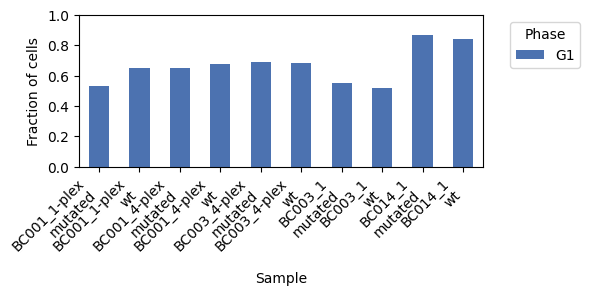

In [6]:
cell_type = 'Early Erythroid'
min_cells = 25

adata_subset = adata[adata.obs['cell_type'] == cell_type, :].copy()
adata_subset = adata_subset[adata_subset.obs['genotype'].isin(['JAK2 c.1849G>T_mutated', 'JAK2 c.1849G>T_wt','JAK2 c.1849G>T_heterozygous'])].copy()

### find samples with at least min cells in both mutated and wt groups
genotypes = ['JAK2 c.1849G>T_mutated','JAK2 c.1849G>T_heterozygous']
samples_to_include = adata_subset[adata_subset.obs['genotype'].isin(genotypes)].obs['sample'].value_counts()
samples_to_include = samples_to_include[samples_to_include >= min_cells].index.tolist()
genotypes = ['JAK2 c.1849G>T_wt']
samples_to_include = adata_subset[(adata_subset.obs['genotype'].isin(genotypes)) & (adata_subset.obs['sample'].isin(samples_to_include))].obs['sample'].value_counts()
samples_to_include = samples_to_include[samples_to_include >= min_cells].index.tolist()
adata_subset.obs['JAK2_genotype'] = adata_subset.obs['genotype'].map({'JAK2 c.1849G>T_heterozygous':'mutated', 'JAK2 c.1849G>T_mutated':'mutated', 'JAK2 c.1849G>T_wt':'wt'})

### get counts of cells in each phase per sample and genotype
phase_counts = adata_subset.obs[['sample','JAK2_genotype','phase']].value_counts().reset_index().sort_values(['sample','JAK2_genotype'])

### reformat and plot samples that were in the homozygous JAK2 mrvi set (all others would have too many heterozygous cells)
df = phase_counts.loc[phase_counts['sample'].isin(set(samples_to_include).intersection(homozygous_jak2_patients))].reset_index(drop=True).copy()
df['sample'] = df['sample'].cat.remove_unused_categories()

# --- Combine sample + genotype for x-axis ---
df["group"] = df["sample"].astype(str) + "_" + df["JAK2_genotype"].astype(str)

# --- Pivot so phases become columns ---
pivot = df.pivot_table(index=["sample", "JAK2_genotype"], columns="phase", values="count", aggfunc="sum", observed=False).fillna(0)
pivot = pivot.div(pivot.sum(axis=1), axis=0)
pivot = 1 - pivot["G1"]  # order phases

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,3))
pivot.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0"])

# --- Beautify ---
xticks = [f"{s}\n{g}" for s, g in pivot.index]
ax.set_xticklabels(xticks, rotation=45, ha="right")
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Sample")
ax.legend(title="Phase", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

ax.set_ylim(0,1)
plt.savefig(f"../plots/{cell_type}_cell_cycle_by_sample_genotype_stacked_bar.pdf", bbox_inches='tight', dpi=300)

diagnosis
PV           3
ET           2
PMF          8
postPV MF    7
postET MF    5
healthy      2
Name: count, dtype: int64


MannwhitneyuResult(statistic=0.0, pvalue=1.238696890870804e-05)

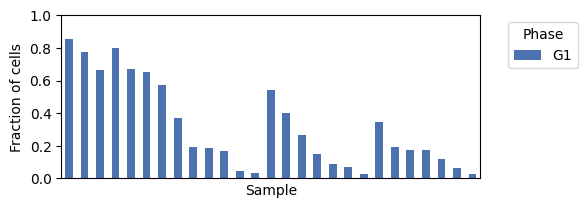

In [7]:
cell_type = 'HSC'
min_cells = 15

patient_diagnoses = patient_metadata[['sample','Diagnosis ']].copy()
diagnoses_to_include = ['PV','ET','PMF','postPV MF','postET MF','healthy']
patient_diagnoses = patient_diagnoses.loc[patient_diagnoses['Diagnosis '].isin(diagnoses_to_include)]
patient_diagnoses = pd.concat([patient_diagnoses, pd.DataFrame([['BC016_1','healthy'],['BC015_2','healthy']], columns=['sample','Diagnosis '])])

patient_diagnoses['Diagnosis '] = pd.Categorical(patient_diagnoses['Diagnosis '], categories=diagnoses_to_include, ordered=True)
patient_diagnoses = patient_diagnoses.sort_values('Diagnosis ')
patients = patient_diagnoses['sample'].tolist()

adata_subset = adata[adata.obs['cell_type'] == cell_type, :].copy()
samples_to_include = adata_subset.obs['sample'].value_counts()
samples_to_include = samples_to_include[samples_to_include >= min_cells].index.tolist()
adata_subset = adata_subset[adata_subset.obs['sample'].isin(samples_to_include)].copy()

### get counts of cells in each phase per sample
phase_counts = adata_subset.obs[['sample','phase']].value_counts().reset_index().sort_values(['sample'])

### reformat and plot samples that were in the homozygous JAK2 mrvi set (all others would have too many heterozygous cells)
df = phase_counts.loc[phase_counts['sample'].isin(patients)].reset_index(drop=True).copy()

df['sample'] = df['sample'].cat.remove_unused_categories()

# --- Combine sample + genotype for x-axis ---
df["group"] = df["sample"].astype(str)

# --- Pivot so phases become columns ---
pivot = df.pivot_table(index=["sample"], columns="phase", values="count", aggfunc="sum", observed=False).fillna(0)
pivot = pivot.div(pivot.sum(axis=1), axis=0)

pivot['diagnosis'] = pivot.index.map(patient_diagnoses.set_index('sample')['Diagnosis '].to_dict())
pivot['diagnosis'] = pd.Categorical(pivot['diagnosis'], categories=diagnoses_to_include, ordered=True)

pivot = pivot.sort_values(['diagnosis','G1'])

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,3))
(1 - pivot["G1"]).plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0"])

# --- Beautify ---
xticks = [f"{s}" for s in pivot.index]
ax.set_xticklabels(xticks, rotation=45, ha="right")
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Sample")
ax.legend(title="Phase", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.xticks([])

ax.set_ylim(0,1)
plt.savefig(f"../plots/{cell_type}_cell_cycle_by_sample_stacked_bar.pdf", bbox_inches='tight', dpi=300)

print(pivot['diagnosis'].value_counts().sort_index())

st.mannwhitneyu(pivot.loc[pivot['diagnosis'].isin(['PV','ET']), 'G1'].dropna(), pivot.loc[~pivot['diagnosis'].isin(['PV','ET']), 'G1'].dropna(), alternative='less')


In [8]:
patients = pivot.index.tolist()

diagnosis
PV           3
ET           2
PMF          8
postPV MF    7
postET MF    5
healthy      2
Name: count, dtype: int64


MannwhitneyuResult(statistic=14.0, pvalue=0.2318840579710145)

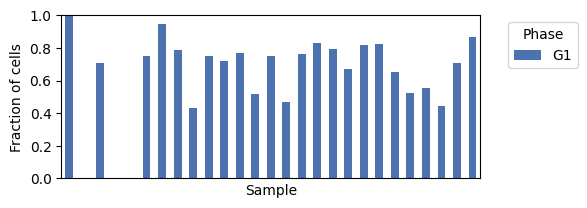

In [9]:
cell_type = 'Early MK'
min_cells = 15

adata_subset = adata[adata.obs['cell_type'] == cell_type, :].copy()
samples_to_include = adata_subset.obs['sample'].value_counts()
samples_to_include = samples_to_include[samples_to_include >= min_cells].index.tolist()
adata_subset = adata_subset[adata_subset.obs['sample'].isin(samples_to_include)].copy()

### get counts of cells in each phase per sample
phase_counts = adata_subset.obs[['sample','phase']].value_counts().reset_index().sort_values(['sample'])

### reformat and plot samples that were in the homozygous JAK2 mrvi set (all others would have too many heterozygous cells)
df = phase_counts.loc[phase_counts['sample'].isin(patients)].reset_index(drop=True).copy()
df['sample'] = df['sample'].cat.remove_unused_categories()
df['sample'] = pd.Categorical(df['sample'], categories=patients, ordered=True)

# --- Combine sample + genotype for x-axis ---
df["group"] = df["sample"].astype(str)

# --- Pivot so phases become columns ---
pivot = df.pivot_table(index=["sample"], columns="phase", values="count", aggfunc="sum", observed=False).fillna(0)
pivot = pivot.div(pivot.sum(axis=1), axis=0)

pivot['diagnosis'] = pivot.index.map(patient_diagnoses.set_index('sample')['Diagnosis '].to_dict())
pivot['diagnosis'] = pd.Categorical(pivot['diagnosis'], categories=diagnoses_to_include, ordered=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,3))
(1 - pivot["G1"]).plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0"]) 

# --- Beautify ---
xticks = [f"{s}" for s in pivot.index]
ax.set_xticklabels(xticks, rotation=45, ha="right")
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Sample")
ax.legend(title="Phase", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.xticks([])
ax.set_ylim(0,1)

plt.savefig(f"../plots/{cell_type}_cell_cycle_by_sample_stacked_bar.pdf", bbox_inches='tight', dpi=300)

print(pivot['diagnosis'].value_counts().sort_index())

st.mannwhitneyu(pivot.loc[pivot['diagnosis'].isin(['PV','ET']), 'G1'].dropna(), pivot.loc[~pivot['diagnosis'].isin(['PV','ET']), 'G1'].dropna(), alternative='less')


diagnosis
PV           3
ET           2
PMF          8
postPV MF    7
postET MF    5
healthy      2
Name: count, dtype: int64


MannwhitneyuResult(statistic=5.0, pvalue=0.006956521739130434)

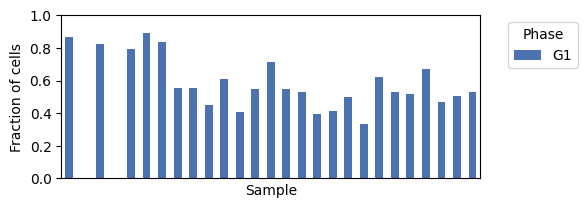

In [10]:
cell_type = 'Early Erythroid'
min_cells = 15

adata_subset = adata[adata.obs['cell_type'] == cell_type, :].copy()
samples_to_include = adata_subset.obs['sample'].value_counts()
samples_to_include = samples_to_include[samples_to_include >= min_cells].index.tolist()
adata_subset = adata_subset[adata_subset.obs['sample'].isin(samples_to_include)].copy()

### get counts of cells in each phase per sample
phase_counts = adata_subset.obs[['sample','phase']].value_counts().reset_index().sort_values(['sample'])

### reformat and plot samples that were in the homozygous JAK2 mrvi set (all others would have too many heterozygous cells)
df = phase_counts.loc[phase_counts['sample'].isin(patients)].reset_index(drop=True).copy()
df['sample'] = df['sample'].cat.remove_unused_categories()
df['sample'] = pd.Categorical(df['sample'], categories=patients, ordered=True)

# --- Combine sample + genotype for x-axis ---
df["group"] = df["sample"].astype(str)

# --- Pivot so phases become columns ---
pivot = df.pivot_table(index=["sample"], columns="phase", values="count", aggfunc="sum", observed=False).fillna(0)
pivot = pivot.div(pivot.sum(axis=1), axis=0)

pivot['diagnosis'] = pivot.index.map(patient_diagnoses.set_index('sample')['Diagnosis '].to_dict())
pivot['diagnosis'] = pd.Categorical(pivot['diagnosis'], categories=diagnoses_to_include, ordered=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,3))
(1 - pivot["G1"]).plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0"])

# --- Beautify ---
xticks = [f"{s}" for s in pivot.index]
ax.set_xticklabels(xticks, rotation=45, ha="right")
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Sample")
ax.legend(title="Phase", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.xticks([])
ax.set_ylim(0,1)

plt.savefig(f"../plots/{cell_type}_cell_cycle_by_sample_stacked_bar.pdf", bbox_inches='tight', dpi=300)

print(pivot['diagnosis'].value_counts().sort_index())

st.mannwhitneyu(pivot.loc[pivot['diagnosis'].isin(['PV','ET']), 'G1'].dropna(), pivot.loc[~pivot['diagnosis'].isin(['PV','ET']), 'G1'].dropna(), alternative='less')


/tmp/ipykernel_1198463/2574785072.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby(subset_adata.obs["sample"]).mean().iloc[:, 0].sort_values(ascending=False)


MannwhitneyuResult(statistic=10.0, pvalue=0.047619047619047616)
MannwhitneyuResult(statistic=25.0, pvalue=0.02121212121212121)


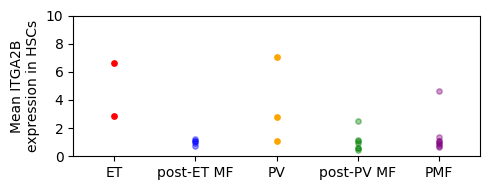

In [ ]:
gene = "ITGA2B"

subset_adata = adata[adata.obs['cell_type'] == 'HSC', :].copy()

# compute mean expression per sample
mean_expr = pd.DataFrame(
    subset_adata.obs[gene + '_scvi_normalized'], 
    index=subset_adata.obs.index
).groupby(subset_adata.obs["sample"]).mean().iloc[:, 0].sort_values(ascending=False)

ET_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '] == "ET"]['sample'].values.tolist()
ET_patients = [patient for patient in ET_patients if patient in mean_expr.index]

postET_MF_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '].isin(['postET MF'])]['sample'].values.tolist()
postET_MF_patients = [patient for patient in postET_MF_patients if patient in mean_expr.index]

postPV_MF_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '].isin(['postPV MF'])]['sample'].values.tolist()
postPV_MF_patients = [patient for patient in postPV_MF_patients if patient in mean_expr.index]

PMF_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '] == "PMF"]['sample'].values.tolist()
PMF_patients = [patient for patient in PMF_patients if patient in mean_expr.index]

PV_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '] == "PV"]['sample'].values.tolist()
PV_patients = [patient for patient in PV_patients if patient in mean_expr.index]

pt_size = 15
fig,ax = plt.subplots(figsize=(5,2))
ax.scatter([1]*len(ET_patients), mean_expr.loc[ET_patients], color='r', label='ET patients', s=pt_size)
ax.scatter([2]*len(postET_MF_patients), mean_expr.loc[postET_MF_patients], color='b', label='post-ET MF patients', s=pt_size, alpha=0.4)

ax.scatter([3]*len(PV_patients), mean_expr.loc[PV_patients], color='orange', label='PV patients', s=pt_size)
ax.scatter([4]*len(postPV_MF_patients), mean_expr.loc[postPV_MF_patients], color='green', label='post-PV MF patients', s=pt_size, alpha=0.4)

ax.scatter([5]*len(PMF_patients), mean_expr.loc[PMF_patients], color='purple', label='PMF patients', s=pt_size, alpha=0.4)

ax.set_xticks([1,2,3,4,5], labels=['ET','post-ET MF', 'PV', 'post-PV MF', 'PMF'])
ax.set_xlim(0.5,5.5)
ax.set_ylabel('Mean ITGA2B\nexpression in HSCs')

print(st.mannwhitneyu(
    mean_expr.loc[ET_patients],
    mean_expr.loc[postET_MF_patients],
    alternative='greater')
)

print(st.mannwhitneyu(
    mean_expr.loc[PV_patients],
    mean_expr.loc[postPV_MF_patients],
    alternative='greater')
)

ax.set_ylim(0, 10)
plt.tight_layout()

plt.savefig(f"../plots/ITGA2B_expression_in_HSCs_ET_vs_MF.pdf", bbox_inches='tight', dpi=300)

/tmp/ipykernel_1198463/469616876.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby(subset_adata.obs["sample"]).mean().iloc[:, 0].sort_values(ascending=False)


MannwhitneyuResult(statistic=10.0, pvalue=0.047619047619047616)
MannwhitneyuResult(statistic=28.0, pvalue=0.0030303030303030303)


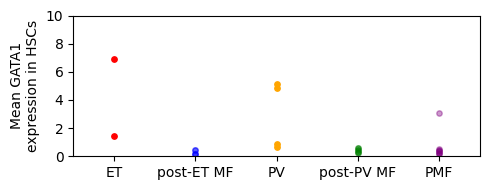

In [15]:
gene = "GATA1"

subset_adata = adata[adata.obs['cell_type'] == 'HSC', :].copy()

# compute mean expression per sample
mean_expr = pd.DataFrame(
    subset_adata.obs[gene + '_scvi_normalized'], 
    index=subset_adata.obs.index
).groupby(subset_adata.obs["sample"]).mean().iloc[:, 0].sort_values(ascending=False)


ET_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '] == "ET"]['sample'].values.tolist()
ET_patients = [patient for patient in ET_patients if patient in mean_expr.index]

postET_MF_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '].isin(['postET MF'])]['sample'].values.tolist()
postET_MF_patients = [patient for patient in postET_MF_patients if patient in mean_expr.index]

postPV_MF_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '].isin(['postPV MF'])]['sample'].values.tolist()
postPV_MF_patients = [patient for patient in postPV_MF_patients if patient in mean_expr.index]

PMF_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '] == "PMF"]['sample'].values.tolist()
PMF_patients = [patient for patient in PMF_patients if patient in mean_expr.index]

PV_patients = patient_diagnoses.loc[patient_diagnoses['Diagnosis '] == "PV"]['sample'].values.tolist()
PV_patients = [patient for patient in PV_patients if patient in mean_expr.index]

fig,ax = plt.subplots(figsize=(5,2))
ax.scatter([1]*len(ET_patients), mean_expr.loc[ET_patients], color='r', label='ET patients', s=pt_size)
ax.scatter([2]*len(postET_MF_patients), mean_expr.loc[postET_MF_patients], color='b', label='post-ET MF patients', s=pt_size, alpha=0.4)

ax.scatter([3]*len(PV_patients), mean_expr.loc[PV_patients], color='orange', label='PV patients', s=pt_size)
ax.scatter([4]*len(postPV_MF_patients), mean_expr.loc[postPV_MF_patients], color='green', label='post-PV MF patients', s=pt_size, alpha=0.4)

ax.scatter([5]*len(PMF_patients), mean_expr.loc[PMF_patients], color='purple', label='PMF patients', s=pt_size, alpha=0.4)

ax.set_xticks([1,2,3,4,5], labels=['ET','post-ET MF', 'PV', 'post-PV MF', 'PMF'])
ax.set_xlim(0.5,5.5)
ax.set_ylabel('Mean GATA1\nexpression in HSCs')

print(st.mannwhitneyu(
    mean_expr.loc[ET_patients],
    mean_expr.loc[postET_MF_patients],
    alternative='greater')
)

print(st.mannwhitneyu(
    mean_expr.loc[PV_patients],
    mean_expr.loc[postPV_MF_patients],
    alternative='greater')
)

ax.set_ylim(0,10)
plt.tight_layout()

plt.savefig(f"../plots/GATA1_expression_in_HSCs_ET_vs_MF.pdf", bbox_inches='tight', dpi=300)